In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
# 1. LOAD THE SAVED MODEL
model_path = '../../models/dropout/rf_dropout_model.joblib'
rf_model = joblib.load(model_path)
print("Model loaded successfully!")

Model loaded successfully!


In [3]:
# 2. LOAD THE TEST DATA
X_test = pd.read_csv('../../data/processed/dropout/X_test.csv')
y_test = pd.read_csv('../../data/processed/dropout/y_test.csv').squeeze() # .squeeze() makes it a 1D array
feature_names = pd.read_csv('../../data/processed/dropout/feature_names.csv').squeeze()

In [4]:
# 3. GENERATE PREDICTIONS
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] 

custom_threshold = 0.4

# Apply the threshold: If risk is >= 0.40, classify as 1 (Dropout)
y_pred_adjusted = (y_pred_proba >= custom_threshold).astype(int)

In [5]:
# 4. PERFORMANCE METRICS
print(f"Threshold:  {custom_threshold * 100}%")
print("\nModel Evaluation")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_adjusted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_adjusted):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_adjusted):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_adjusted):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

Threshold:  40.0%

Model Evaluation
Accuracy:  0.7648
Precision: 0.5837
Recall:    0.8552
F1-Score:  0.6938
AUC-ROC:   0.8797



Generating Actionable Insights (Risk Factors)


/var/folders/b3/0fd8bgg112d1_6p01j251slr0000gn/T/ipykernel_73468/2337510187.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Risk_Factor', data=importance_df.head(10), palette='magma')


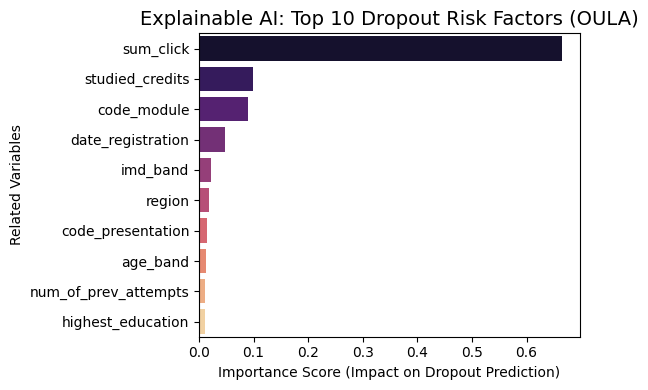

In [6]:
# 5. EXPLAINABLE AI: FEATURE IMPORTANCE
print("\nGenerating Actionable Insights (Risk Factors)")
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Risk_Factor': feature_names,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

# Plotting the top 10 reasons for dropout risk
plt.figure(figsize=(6, 4))
sns.barplot(x='Importance_Score', y='Risk_Factor', data=importance_df.head(10), palette='magma')
plt.title('Explainable AI: Top 10 Dropout Risk Factors (OULA)', fontsize=14)
plt.xlabel('Importance Score (Impact on Dropout Prediction)')
plt.ylabel('Related Variables')
plt.tight_layout()
plt.show()